# Exploratory Data Analysis: Stanford Dogs and OOD Dataset

**Course:** MAI202 – Deep Learning  
**Project:** Dog Breed Classification with Out-of-Distribution Detection  
**Notebook:** `01_eda.ipynb`  
**Author:** Soodeh Vanaki  

## Objective

This notebook presents an exploratory analysis of the Stanford Dogs dataset before model training.

The purpose is to understand the dataset characteristics and identify preprocessing, augmentation, and modeling considerations for the ResNet-18 dog-breed classifier.

The analysis focuses on:

1. Dataset structure and breed coverage
2. Class-distribution characteristics
3. Representative dog-breed images
4. Image-size and aspect-ratio variability
5. Bounding-box cropping considerations
6. Potential class-imbalance concerns
7. Recommendations for preprocessing and model training

### Import Libraries

In [10]:
from pathlib import Path
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Make notebook outputs reproducible
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Imports completed successfully.")

Imports completed successfully.


### Project Path Configuration

In [ ]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

IMAGES_DIR = RAW_DATA_DIR / "Images"
ANNOTATIONS_DIR = RAW_DATA_DIR / "Annotation"
LISTS_DIR = RAW_DATA_DIR / "lists"

EDA_PLOTS_DIR = PROJECT_ROOT / "reports" / "eda_plots"
EDA_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images:", IMAGES_DIR)
print("Annotations:", ANNOTATIONS_DIR)
print("Lists:", LISTS_DIR)

Project root: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector
Images: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Images
Annotations: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Annotation
Lists: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\lists


## 1. Dataset Overview

The Stanford Dogs dataset is designed for fine-grained image classification, where the model must distinguish between visually similar dog breeds. The dataset contains 120 breed categories and approximately 20,000 images.

This creates a challenging classification problem because many breeds share similar visual characteristics, including coat colour, body shape, facial structure, and size. At the same time, images may differ in background, lighting, camera angle, pose, scale, and resolution.

These characteristics suggest that the model should use transfer learning, consistent image resizing, normalization, data augmentation, and bounding-box cropping where available.

### Verify the dataset

In [13]:
for folder in [IMAGES_DIR, ANNOTATIONS_DIR, LISTS_DIR]:
    print(f"{folder.name}: {folder.exists()}")

Images: True
Annotation: True
lists: True


### Count breeds

In [14]:
breed_folders = sorted([d for d in IMAGES_DIR.iterdir() if d.is_dir()])

print("Number of breeds:", len(breed_folders))
print()

print("First 10 breeds:")

for breed in breed_folders[:10]:
    print("-", breed.name)

Number of breeds: 120

First 10 breeds:
- n02085620-Chihuahua
- n02085782-Japanese_spaniel
- n02085936-Maltese_dog
- n02086079-Pekinese
- n02086240-Shih-Tzu
- n02086646-Blenheim_spaniel
- n02086910-papillon
- n02087046-toy_terrier
- n02087394-Rhodesian_ridgeback
- n02088094-Afghan_hound


### Count images per breed

In [16]:
breed_counts = []

for breed in breed_folders:
    image_count = len(list(breed.glob("*.jpg")))
    breed_counts.append(
        {
            "Breed": breed.name,
            "Images": image_count
        }
    )

breed_df = pd.DataFrame(breed_counts)

breed_df.head()

,Breed,Images
0,n02085620-Chihuahua,152
1,n02085782-Japanese_spaniel,185
2,n02085936-Maltese_dog,252
3,n02086079-Pekinese,149
4,n02086240-Shih-Tzu,214


### Summary statistics

In [17]:
breed_df.describe()

,Images
count,120.000000
mean,171.500000
std,23.220898
min,148.000000
25%,152.750000
50%,159.500000
75%,186.250000
max,252.000000


In [18]:
print("Total breeds:", len(breed_df))
print("Total images:", breed_df["Images"].sum())

print()

print("Minimum images:", breed_df["Images"].min())
print("Maximum images:", breed_df["Images"].max())
print("Average images:", breed_df["Images"].mean())

Total breeds: 120
Total images: 20580

Minimum images: 148
Maximum images: 252
Average images: 171.5


### Create the first figure

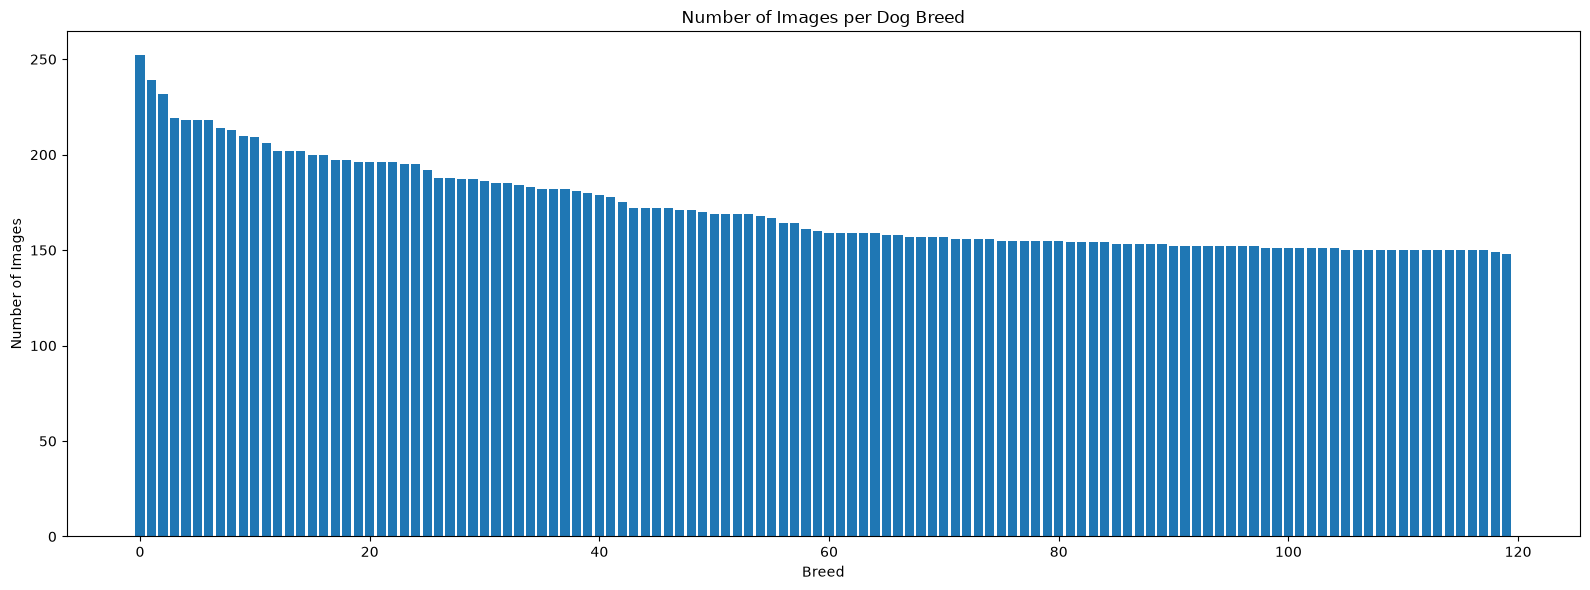

In [19]:
plt.figure(figsize=(16,6))

breed_df = breed_df.sort_values("Images", ascending=False)

plt.bar(range(len(breed_df)), breed_df["Images"])

plt.title("Number of Images per Dog Breed")
plt.xlabel("Breed")
plt.ylabel("Number of Images")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. Breed and Class Distribution

## 3. Representative Image Samples

## 4. Image Dimensions and Aspect Ratios

## 5. Bounding-Box Cropping Analysis

## 6. Potential Data Challenges

## 7. Preprocessing and Augmentation Recommendations

## 8. Key Findings for Model Training